# Example of calibration for simple time series model

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

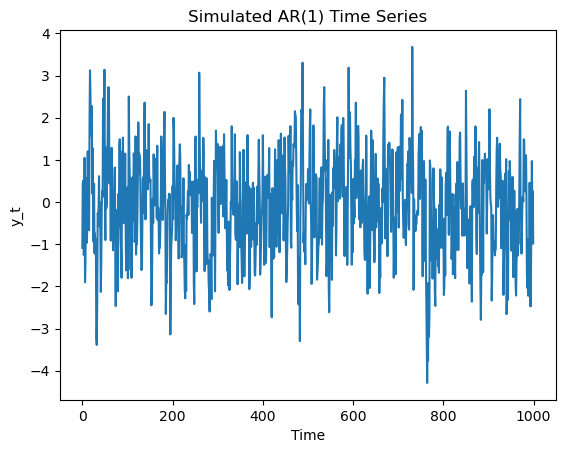

In [2]:
np.random.seed(123)
n = 1000

# --- Generate AR(1) series y_t = 0.5 y_{t-1} + eps_t ---
sd0 = 1
eps = np.random.normal(0, sd0, n)

y = np.zeros(n)
y[0] = eps[0]
for t in range(1, n):
    y[t] = 0.5 * y[t - 1] + eps[t]

plt.plot(np.arange(n), y)
plt.title("Simulated AR(1) Time Series")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.show()


In [3]:
# --- Construct lagged dataframe
Y_true = pd.DataFrame({
    "y": y[1:],          # current value
    "y1": y[:-1]         # lag 1
})

# --- OLS: y ~ y1 - 1 (no intercept) ---
model = sm.OLS(Y_true["y"], Y_true["y1"])
results = model.fit()
Y_fitted = results.fittedvalues.values

# --- Bias & dispersion grid --- 
# This is induced distance between the true parameter value and the estimated one. Where bias is the error in the mean estimate, dispersion is the error in the variance estimate.
# Note  that for a AR(1) process the dispersion is not estimated.
bias_vals = [-0.5, -0.3, -0.1, 0, 0.1, 0.3, 0.5]
disp_vals = [-0.5, -0.3, -0.1, 0, 0.1, 0.3, 0.5]

bias_disp = pd.DataFrame(
    [(b, d) for b in bias_vals for d in disp_vals],
    columns=["bias", "dispersion"]
)
bias_disp.head()

,bias,dispersion
0,-0.5,-0.5
1,-0.5,-0.3
2,-0.5,-0.1
3,-0.5,0.0
4,-0.5,0.1


In [5]:
# --- Compute PIT values ---
rows = []
for _, row in bias_disp.iterrows():
    b = row["bias"]
    d = row["dispersion"]
    
    pit = norm.cdf(
        Y_true["y"], 
        loc=Y_fitted + b, 
        scale=np.sqrt(1 + d)
    )
    
    df_tmp = pd.DataFrame({
        "bias": b,
        "dispersion": d,
        "pit": pit
    })
    rows.append(df_tmp)

hist_dat = pd.concat(rows, ignore_index=True)

# Convert dispersion to ordered factor needed for plotting the facet grid
hist_dat["dispersion"] = pd.Categorical(
    hist_dat["dispersion"],
    categories=sorted(hist_dat["dispersion"].unique(), reverse=True),
    ordered=True
)


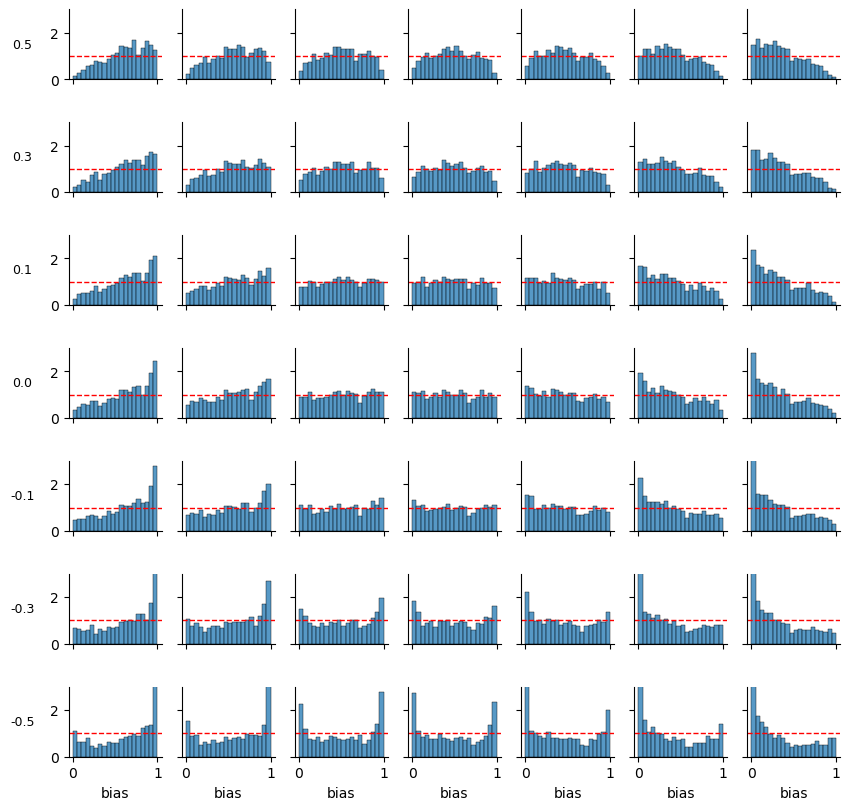

In [11]:
# --- PIT histogram grid ---
g = sns.FacetGrid(
    hist_dat, 
    row="dispersion", 
    col="bias", 
    sharey=True,
    sharex=True,
    margin_titles=False,
    height=1.2
)

g.map_dataframe(
    sns.histplot,
    x="pit", 
    stat="density", 
    binwidth=0.05, 
    binrange=(0,1)
)
g.refline(y=1, color="red", linestyle="--", linewidth=1)
# Global labels for grid
g.set_titles("")
g.set_xlabels("bias")
g.set_ylabels("dispersion")
g.set(ylim=(0, 3))


for ax, row_name in zip(g.axes[:,0], hist_dat["dispersion"].cat.categories):
    ax.set_ylabel(row_name, rotation=0, labelpad=20, fontsize=9, va="center")

plt.show()


In [ ]:
zip